# Ensemble Narrative Topic Modeling

**Pipeline Edition**

We combine topic models across all source texts to produce an ensemble representation of the narrative structure of the Popol Wuj.

Each source text is processed through an identical sklearn `Pipeline`:

```
NarrativeParserStep  →  NarrativeModelStep
(DOC → TFIDF)           (TFIDF → THETA / PHI / TOPIC)
```

Wrapping the library classes in sklearn-compatible transformers gives us:
- A single, reproducible entry point (`pipeline.fit(DOC)`) per source
- Automatic parameter exposure via `stepname__param` for future grid search
- A principled `pipeline.transform()` for projecting new documents into topic space
- Clean separation between source configuration and fitted state

## Config

In [1]:
class Params:
    # Parser
    n_chunks  : int   = 33    # Number of equal narrative chunks to divide the text into
    no_above  : float = 0.5   # Max DF threshold for vocabulary selection
    
    # Model
    n_topics  : int   = 6     # Number of NMF topics
    alpha     : float = 0.0   # NMF regularisation (alpha_W and alpha_H)

In [2]:
# base_path = "/content/drive/Othercomputers/My Mac/Repos/Multepal/pv-narrative"
base_path = "/Users/rca2t/Repos/Multepal/pv-narrative"
local_lib  = "../../local_lib"
data_home  = "../"
output_dir = "output"
image_dir  = "figures"

## Imports

In [3]:
import sys; sys.path.append(local_lib)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
# from great_tables import GT

# from sklearn.base    import BaseEstimator, TransformerMixin
from narrative_parser import NarrativeParser, NarrativeParserStep
from narrative_model  import NarrativeModel, NarrativeModelStep

from sklearn.pipeline import Pipeline

In [4]:
sys.path.append(base_path + "/local_lib")
sns.set_theme(style='white')

## Source Registry

Each entry describes a source text. Language tag is metadata only;
all pipeline parameters come from `Params`.

Commented-out sources and column-reorder hints are preserved for reference.

In [5]:
SOURCES = {
    'ajtzibab'           : dict(lang='quc'),
    'christenson'        : dict(lang='quc'),
    'colop'              : dict(lang='quc'),
    'christenson_ximenez': dict(lang='quc'),
    'christenson_english_prose': dict(lang='eng'),
    'ximenez'          : dict(lang='quc'),
    'recinos'          : dict(lang='spa'),
    'tedlock'          : dict(lang='eng'),
}

print("Sources:", list(SOURCES.keys()))

Sources: ['ajtzibab', 'christenson', 'colop', 'christenson_ximenez', 'christenson_english_prose', 'ximenez', 'recinos', 'tedlock']


## Load Helper

In [6]:
def import_source(src_id):
    """Load the DOC table for a given source."""
    src_path    = f"{base_path}/notebooks/{src_id}"
    # doc_idx     = open(f"{src_path}/{src_id}-DOC_idx.txt").read().split(",")
    doc_idx = 'doc_id'
    DOC         = pd.read_csv(f"{src_path}/{src_id}-DOC.csv").set_index(doc_idx)
    return DOC

# sklearn-Compatible Wrappers

We wrap `NarrativeParser` and `NarrativeModel` in thin sklearn transformers.
The wrappers live here in the notebook rather than in the library files:
sklearn concerns belong with the sklearn-facing code, not in the domain library.

**Design rule:** the final step's `__init__` name must be `'clf'` in the
multi-model notebook, but here we use `'parser'` and `'model'` as step names
since these are domain-meaningful and there is no SALEX extraction convention
to honour.

# Build Pipeline Registry

One Pipeline per source. All share the same parameters from `Params`.
To add a new source, add one entry to `SOURCES` — nothing else changes.

In [7]:
PIPELINES = {
    src_id: Pipeline([
        ('parser', NarrativeParserStep(
                       src_id,
                       n_chunks = Params.n_chunks,
                       no_above = Params.no_above)),
        ('model',  NarrativeModelStep(
                       n_topics = Params.n_topics,
                       alpha    = Params.alpha)),
    ])
    for src_id in SOURCES
}

# Inspect one pipeline's parameter space
list(PIPELINES.values())[0].get_params()

{'memory': None,
 'steps': [('parser',
   NarrativeParserStep(n_chunks=33, no_above=0.5, src_id='ajtzibab')),
  ('model', NarrativeModelStep())],
 'transform_input': None,
 'verbose': False,
 'parser': NarrativeParserStep(n_chunks=33, no_above=0.5, src_id='ajtzibab'),
 'model': NarrativeModelStep(),
 'parser__n_chunks': 33,
 'parser__no_above': 0.5,
 'parser__src_id': 'ajtzibab',
 'model__alpha': 0.0,
 'model__n_topics': 6}

# Fit All Pipelines

`pipeline.fit_transform(DOC)` runs the full parse-and-model sequence and
returns the reordered THETA for each source.

In [8]:
THETA_dict = {}
TOPIC_dict = {}

for src_id, pipeline in PIPELINES.items():
    print(src_id)
    DOC = import_source(src_id)

    # Fit the pipeline and collect the reordered THETA
    THETA_dict[src_id] = pipeline.fit_transform(DOC)

    # Collect TOPIC metadata (already reordered inside the model step)
    model_step = pipeline.named_steps['model']
    topic      = model_step.model_.TOPIC
    TOPIC_dict[src_id] = model_step._apply_order(topic.T).T

print("\nAll pipelines fitted.")

ajtzibab
christenson
colop
christenson_ximenez
christenson_english_prose
ximenez
recinos
tedlock

All pipelines fitted.


# Consolidate Results

`THETA` and `TOPIC` are keyed by source, mirroring the structure of
`RESULTS` and `SALEX_ALL` in the multi-model classification notebook.

In [9]:
THETA = pd.concat(THETA_dict, names=['src_id', 'chunk_num'])
THETA_mean = THETA.groupby('chunk_num', observed=False).mean()
TOPIC = pd.concat(TOPIC_dict, names=['src_id', 'topic_id'])
print(f"THETA : {THETA.shape}   (src × chunk, topic)")
print(f"TOPIC : {TOPIC.shape}   (src × topic, metadata)")
THETA.head(3)

THETA : (264, 6)   (src × chunk, topic)
TOPIC : (48, 3)   (src × topic, metadata)


0             1             2             3  \
src_id   chunk_num                                                           
ajtzibab 0          3.914186e-01  5.546033e-17  4.897319e-22  4.883028e-24   
         1          4.115652e-01  2.585570e-16  2.131867e-26  2.551144e-23   
         2          2.506060e-22  4.238016e-01  3.197708e-23  3.075297e-26   

                               4             5  
src_id   chunk_num                              
ajtzibab 0          5.360368e-16  7.871273e-16  
         1          3.060304e-21  1.190052e-36  
         2          1.251664e-19  3.465411e-28

# Compare Topics

Compare topic glosses across sources to verify alignment.

In [10]:
TOPIC_gloss = TOPIC.top_terms.unstack(level='src_id')
TOPIC_gloss.index.name = 'topic_id'
TOPIC_gloss.index = [f"T{i}" for i in TOPIC_gloss.index]
print(TOPIC_gloss.reset_index())

src_id index                                      ajtzibab  \
0         T0        alom, k'ajolom, tz'aqol, b'itol, saqil   
1         T1  kaqix, sipakna, k'ajolab', kab'raqan, omuch'   
2         T2        kame, xib'alb'a, k'ajolab', kik', xcha   
3         T3        tojil, q'apojib', amaq', ati't, b'atz'   
4         T4        tojil, k'itze', amaq', q'ij, majukutaj   
5         T5            ajaw, ajpop, unim, k'iche', q'alel   

src_id                                 christenson  \
0               b'it, tz'aq, alom, k'ajolom, saqil   
1        kaqix, k'ajolab', sipakna, jul, kab'raqan   
2       xib'alb'a, kame, kotz'i'j, kik', k'ajolab'   
3            q'apoj, ati't, kati't, chowen, b'atz'   
4        tojil, amaq', kitze, majukutaj, k'ab'awil   
5               pop, tinamit, k'iche', le', q'alel   

src_id                                       colop  \
0           k'ajolom, alom, b'itol, tz'aqol, saqil   
1       kak'ix, sipakna, k'ajolab', jul, kab'raqan   
2         kame, xib'alb'

# Visualize Topics over Narrative Time

Define a display order that reflects the movement of the narrative
from creation to kingship.

In [11]:
viz_order = list(reversed(range(Params.n_topics)))
viz_order

[5, 4, 3, 2, 1, 0]

## Individual Texts

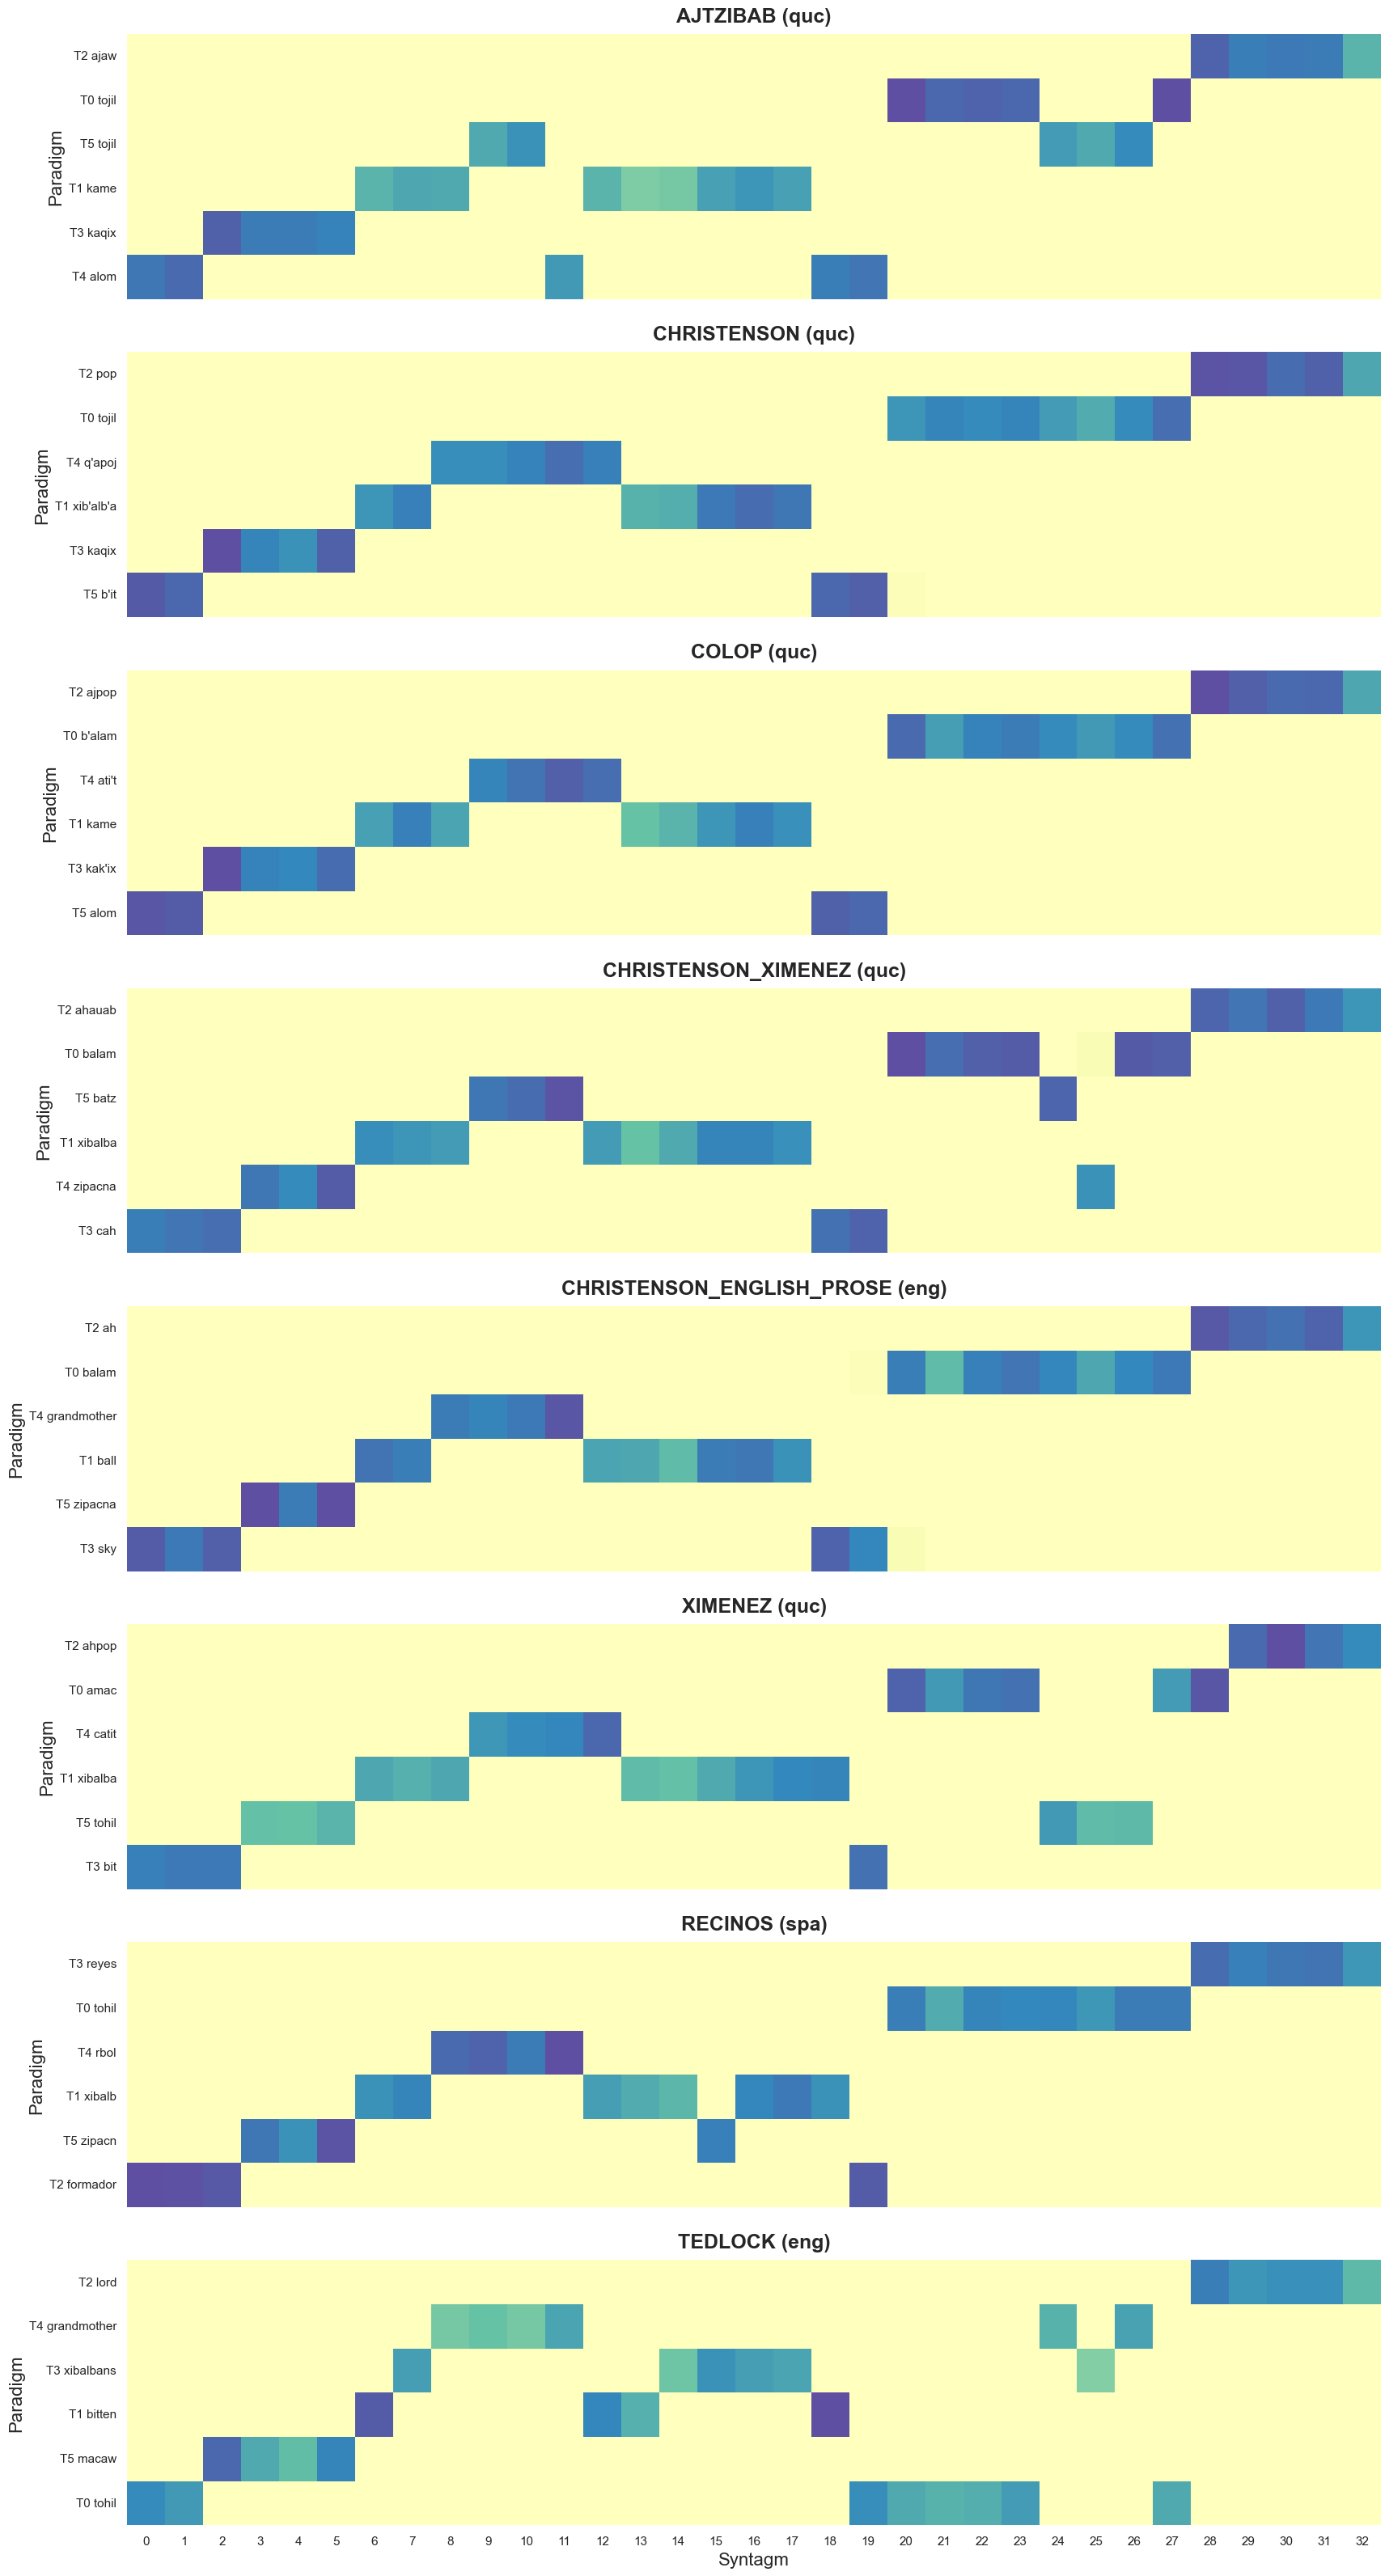

In [12]:
def plot_topics_over_time(src_ids):
    n = len(src_ids)
    fig, axes = plt.subplots(n, 1, figsize=(20, 5 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, src_id in zip(axes, src_ids):
        model_step = PIPELINES[src_id].named_steps['model']
        y_labels   = TOPIC.loc[src_id].loc[viz_order, 'label']
        X          = THETA.loc[src_id].T.loc[viz_order].set_index(y_labels)
        sns.heatmap(X, cmap='Spectral', center=0, cbar=None, ax=ax)
        lang = SOURCES[src_id]['lang']
        ax.set_title(f"{src_id.upper()} ({lang})", fontsize=18,
                     fontweight='bold', y=1.02)
        ax.set_xlabel("")
        ax.set_ylabel("Paradigm", fontsize=16)
    plt.xlabel("Syntagm", fontsize=16)
    # plt.savefig(f"{image_dir}/all-topic-over-doc.png")
    # plt.savefig(f"{image_dir}/all-topic-over-doc.svg")
    plt.show()

plot_topics_over_time(list(SOURCES.keys()))

## Ensemble of All Texts

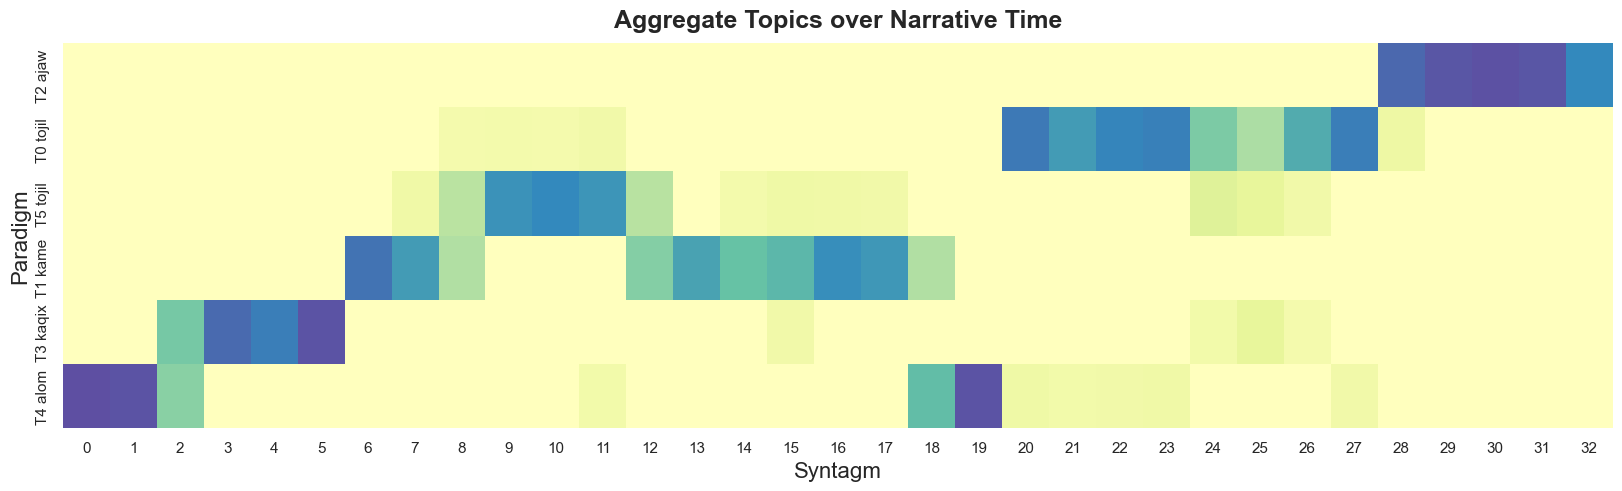

In [13]:
# Use topic labels from the first source as the reference glosses
ref_src    = list(SOURCES.keys())[0]
y_labels   = TOPIC.loc[ref_src].loc[viz_order, 'label']

fig, ax = plt.subplots(figsize=(20, 5))
sns.heatmap(
    THETA_mean.T.loc[viz_order].set_index(y_labels),
    cmap='Spectral', center=0, cbar=None
)
plt.title("Aggregate Topics over Narrative Time", fontsize=18,
          fontweight='bold', y=1.02)
ax.set_xlabel("Chunk Number", fontsize=10)
ax.set_ylabel("Topic",        fontsize=10)
plt.xlabel("Syntagm",  fontsize=16)
plt.ylabel("Paradigm", fontsize=16)
# plt.savefig(f"{image_dir}/ensemble-topic-over-doc.svg", bbox_inches='tight')
# plt.savefig(f"{image_dir}/ensemble-topic-over-doc.png", bbox_inches='tight')
plt.show()

# Apply Models to Original Text Divisions

The original notebook's `TestModel` applied each source's fitted topic-term
matrix (PHI) back to the text at a different OHCO level — e.g. by stanza or
chapter rather than by even chunk.

With the Pipeline, this is handled by calling `pipeline.named_steps['model']
.transform(new_parser)` where `new_parser` is a parser that has been run at
the desired granularity. `NarrativeModelStep.transform()` projects the new
TFIDF into the fitted topic space via `C = PHI @ TFIDF.T`.

`ohco_offset` controls how many levels of the OHCO index to drop when grouping
tokens into structural units — 1 removes the token level, 2 removes the token
and sub-document level.

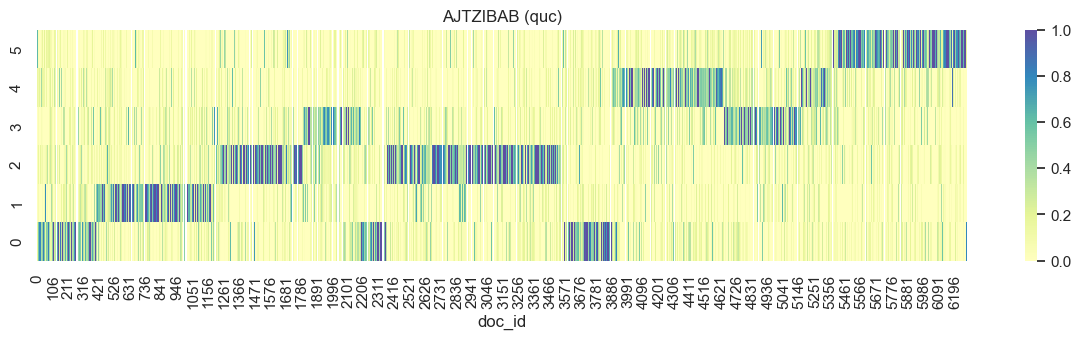

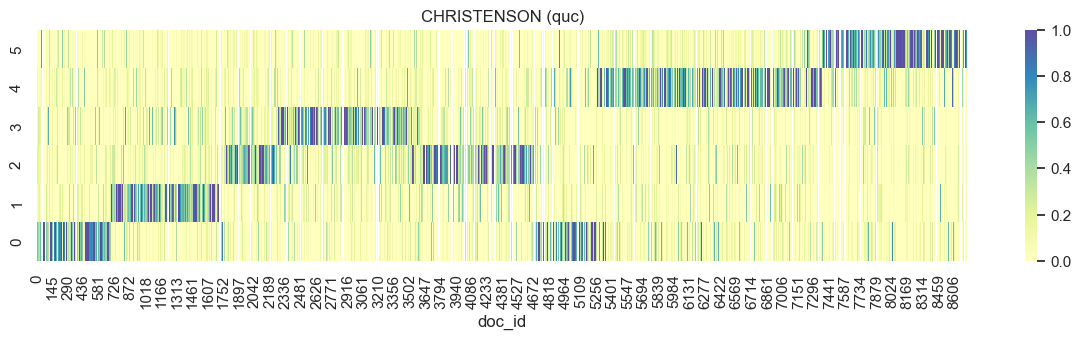

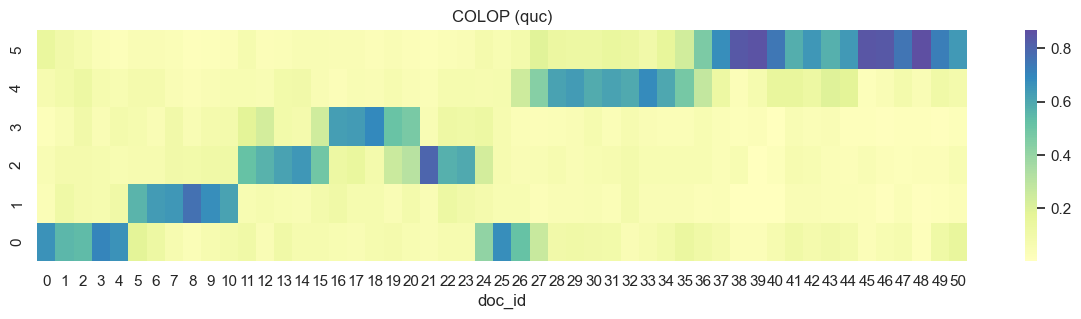

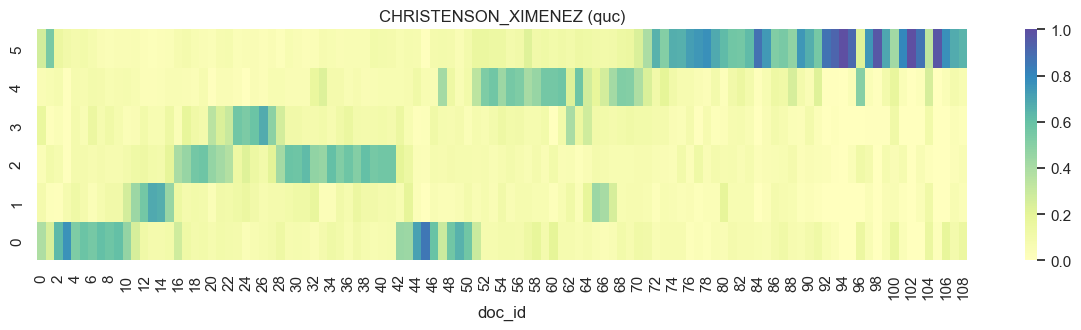

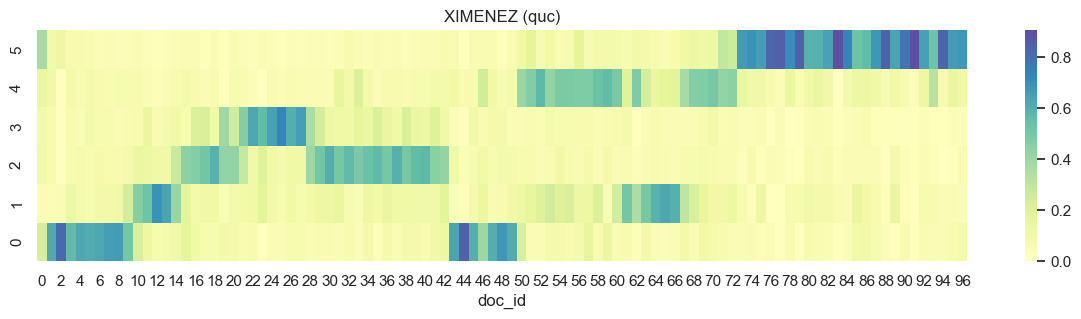

In [14]:
def apply_to_structural_units(src_id, ohco_offset=1):
    """
    Re-parse a source at a structural (non-chunk) granularity and project
    its TF-IDF representation into the fitted topic space.

    Returns C: a (topics × structural-units) DataFrame normalised to proportions.
    """
    pipeline    = PIPELINES[src_id]
    parser_step = pipeline.named_steps['parser']
    model_step  = pipeline.named_steps['model']

    # Build a new parser that groups by structural units instead of even chunks
    orig_parser = parser_step.parser_
    # ohco        = orig_parser.TOKEN.index.names[:-(ohco_offset)]

    # Construct a lightweight parser-like object carrying the re-grouped TFIDF
    class StructuralParser:
        def __init__(self):
            raw   = (
                orig_parser.TOKEN
                # .groupby(ohco + ['term_str'], observed=True)
                .groupby(['doc_id', 'term_str'], observed=True)
                .term_str.count()
                .unstack(fill_value=0)
            )
            TF    = raw
            DF    = (TF > 0).sum()
            IDF   = np.log2((len(TF) + 1) / (DF + 1) + 1)
            TFIDF = TF * IDF
            l2    = np.sqrt((TFIDF ** 2).sum(axis=1))
            self.TFIDF = TFIDF.div(l2, axis=0)

    struct_parser = StructuralParser()
    return model_step.transform(struct_parser)


# Run for all K'iche' sources
for src_id in SOURCES:
    if SOURCES[src_id]['lang'] == 'quc':
        ohco_offset = 2 if src_id == 'ajtzibab' else 1
        C = apply_to_structural_units(src_id, ohco_offset=ohco_offset)
        fig, ax = plt.subplots(figsize=(15, 3))
        sns.heatmap(C.loc[viz_order], cmap='Spectral', center=0)
        plt.title(f"{src_id.upper()} ({SOURCES[src_id]['lang']})")
        plt.show()

# Conclusions

- The Popol Wuj has 8 distinct narrative sections — 2 parts with 5 chapters
  in the first and 3 in the second.
- A 4th chapter (on Blood Woman) is evident in the model but absent in any
  of the segmented printed editions.
- The chapters follow a sequence from cosmogony to anthropogony to sociogony.
- Part I follows a chiasmatic structure in which Blood Woman is the pivot.
- Chiasmatic structure is evident in the Ximénez transcriptions.